# 📊 Phân tích & Đánh giá Dữ liệu Phân nhóm (grouping/ EDA)

Notebook này được thiết kế để phân tích khám phá dữ liệu (EDA) trên tập dữ liệu đã gộp nhóm (`Bird`, `Frog`, `Insect`) trên Google Drive.

### 🎯 Mục tiêu:
1. **Kiểm tra tính nhất quán (Preprocessing Alignment):** Đảm bảo tất cả các tệp `.pt` ở cả 3 nhóm đều tuân thủ đúng định dạng RGB Mel-spectrogram có kích thước `(3, 224, 224)` và có cùng phạm vi giá trị chuẩn hóa.
2. **Phân tích thống kê đặc trưng:** So sánh giá trị trung bình (mean), độ lệch chuẩn (std), giá trị nhỏ nhất (min), và lớn nhất (max) của các tensor giữa 3 nhóm nhằm phát hiện sự lệch pha (distribution shift) có thể gây ảnh hưởng xấu tới quá trình huấn luyện backbone EfficientNet.
3. **Trực quan hóa Spectrogram:** Vẽ biểu đồ so sánh trực quan các dải âm học của các loài chim, ếch và côn trùng.

In [1]:
# Cài đặt và import các thư viện
!pip install -q torch torchvision matplotlib seaborn pandas tqdm

from google.colab import drive
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm

sns.set_theme(style="whitegrid")

# Kết nối Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Google Drive đã kết nối [OK]")

Mounted at /content/drive


In [2]:
DRIVE_DIR = '/content/drive/MyDrive/Datasets/BioListenVN'
GROUPING_DIR = os.path.join(DRIVE_DIR, 'grouping')

folders = ['Bird', 'Frog', 'Insect']
stats_summary = {}

print("--- THỐNG KÊ SỐ LƯỢNG MẪU TẠI CÁC THƯ MỤC DRIVE ---")
for folder in folders:
    folder_path = os.path.join(GROUPING_DIR, folder)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith('.pt')]
        stats_summary[folder] = files
        print(f"Thư mục {folder}: có {len(files)} tệp tin PyTorch tensor (.pt)")
    else:
        print(f"❌ Cảnh báo: Không tìm thấy thư mục {folder_path}")

--- THỐNG KÊ SỐ LƯỢNG MẪU TẠI CÁC THƯ MỤC DRIVE ---
Thư mục Bird: có 796 tệp tin PyTorch tensor (.pt)
Thư mục Frog: có 420 tệp tin PyTorch tensor (.pt)
Thư mục Insect: có 1500 tệp tin PyTorch tensor (.pt)


## 1. Trích xuất Thống kê Thống nhất & Phân phối Giá trị

Chúng ta sẽ lấy ngẫu nhiên 100 mẫu từ mỗi nhóm để phân tích thống kê chi tiết của tensor, bao gồm kích thước (shape), giá trị trung bình (mean), độ lệch chuẩn (std), khoảng giá trị min-max.

In [3]:
sample_records = []
num_samples_to_analyze = 100

for folder, files in stats_summary.items():
    folder_path = os.path.join(GROUPING_DIR, folder)
    # Chọn ngẫu nhiên tối đa 100 file
    selected_files = random.sample(files, min(num_samples_to_analyze, len(files)))

    print(f"Đang phân tích {len(selected_files)} tệp trong thư mục {folder}...")
    for fname in tqdm(selected_files):
        fpath = os.path.join(folder_path, fname)
        try:
            tensor = torch.load(fpath, map_location='cpu')

            # Lấy thông số thống kê
            shape_str = str(list(tensor.shape))
            mean_val = float(tensor.mean())
            std_val = float(tensor.std())
            min_val = float(tensor.min())
            max_val = float(tensor.max())

            sample_records.append({
                'folder': folder,
                'file_name': fname,
                'shape': shape_str,
                'mean': mean_val,
                'std': std_val,
                'min': min_val,
                'max': max_val
            })
        except Exception as e:
            print(f"Lỗi đọc file {fname}: {e}")

df_eda = pd.DataFrame(sample_records)
print(f"\nHoàn tất phân tích thống kê nhanh cho {len(df_eda)} tệp.")
display(df_eda.head())

Đang phân tích 100 tệp trong thư mục Bird...


100%|██████████| 100/100 [00:35<00:00,  2.82it/s]


Đang phân tích 100 tệp trong thư mục Frog...


100%|██████████| 100/100 [00:44<00:00,  2.26it/s]


Đang phân tích 100 tệp trong thư mục Insect...


100%|██████████| 100/100 [00:38<00:00,  2.56it/s]


Hoàn tất phân tích thống kê nhanh cho 300 tệp.


,folder,file_name,shape,mean,std,min,max
0,Bird,398e818ec_s11_13.93.pt,"[3, 224, 224]",0.348856,0.129017,0.060570,0.992513
1,Bird,9f8fcb625_s23_55.81.pt,"[3, 224, 224]",0.370304,0.099975,0.086961,0.977572
2,Bird,352bc8d36_s21_2.80.pt,"[3, 224, 224]",0.360336,0.135700,0.039335,0.976516
3,Bird,ecd47f7cc_s23_20.23.pt,"[3, 224, 224]",0.306043,0.085457,0.051413,0.991382
4,Bird,942ca05c0_s16_1.38.pt,"[3, 224, 224]",0.324469,0.090933,0.047566,0.972904


In [4]:
# Kiểm tra tính đồng nhất của Shape đầu vào
unique_shapes = df_eda.groupby('folder')['shape'].unique()
print("--- KIỂM TRA ĐỒNG NHẤT HÌNH DẠNG TENSOR (SHAPE) ---")
for folder, shapes in unique_shapes.items():
    print(f"Thư mục {folder} chứa các shape: {shapes}")

print("\n--- THỐNG KÊ MÔ TẢ THEO TỪNG THƯ MỤC ---")
display(df_eda.groupby('folder')[['mean', 'std', 'min', 'max']].describe().T)

--- KIỂM TRA ĐỒNG NHẤT HÌNH DẠNG TENSOR (SHAPE) ---
Thư mục Bird chứa các shape: ['[3, 224, 224]']
Thư mục Frog chứa các shape: ['[3, 224, 224]']
Thư mục Insect chứa các shape: ['[3, 224, 224]']

--- THỐNG KÊ MÔ TẢ THEO TỪNG THƯ MỤC ---


folder            Bird        Frog      Insect
mean count  100.000000  100.000000  100.000000
     mean     0.342704    0.355512    0.465005
     std      0.046119    0.051138    0.124975
     min      0.230541    0.249787    0.219841
     25%      0.313429    0.321320    0.376451
     50%      0.346334    0.349993    0.444241
     75%      0.376237    0.393031    0.557843
     max      0.447606    0.534660    0.802722
std  count  100.000000  100.000000  100.000000
     mean     0.110084    0.121303    0.155347
     std      0.023419    0.026744    0.066833
     min      0.066776    0.075103    0.055794
     25%      0.093761    0.097327    0.111434
     50%      0.106471    0.121580    0.141919
     75%      0.127472    0.144087    0.183041
     max      0.188998    0.179129    0.380841
min  count  100.000000  100.000000  100.000000
     mean     0.057408    0.051576    0.038215
     std      0.030206    0.034652    0.029399
     min      0.010308    0.009437    0.000000
     25%      0.035167    0.029350    0.017827
     50%      0.051592    0.044716    0.033929
     75%      0.076380    0.061470    0.053603
     max      0.146906    0.284286    0.144754
max  count  100.000000  100.000000  100.000000
     mean     0.977965    0.978104    0.984113
     std      0.011411    0.012795    0.013459
     min      0.939332    0.939973    0.926136
     25%      0.970965    0.970939    0.979999
     50%      0.979611    0.979019    0.986727
     75%      0.986080    0.988223    0.993041
     max      0.995947    0.996673    0.999977

## 2. Trực quan hóa Sự phân bố Giá trị qua các nhóm (Distribution Analysis)

Chúng ta sẽ vẽ các biểu đồ hộp (Boxplots) để so sánh các chỉ số thống kê của tensor giữa các lớp dữ liệu.

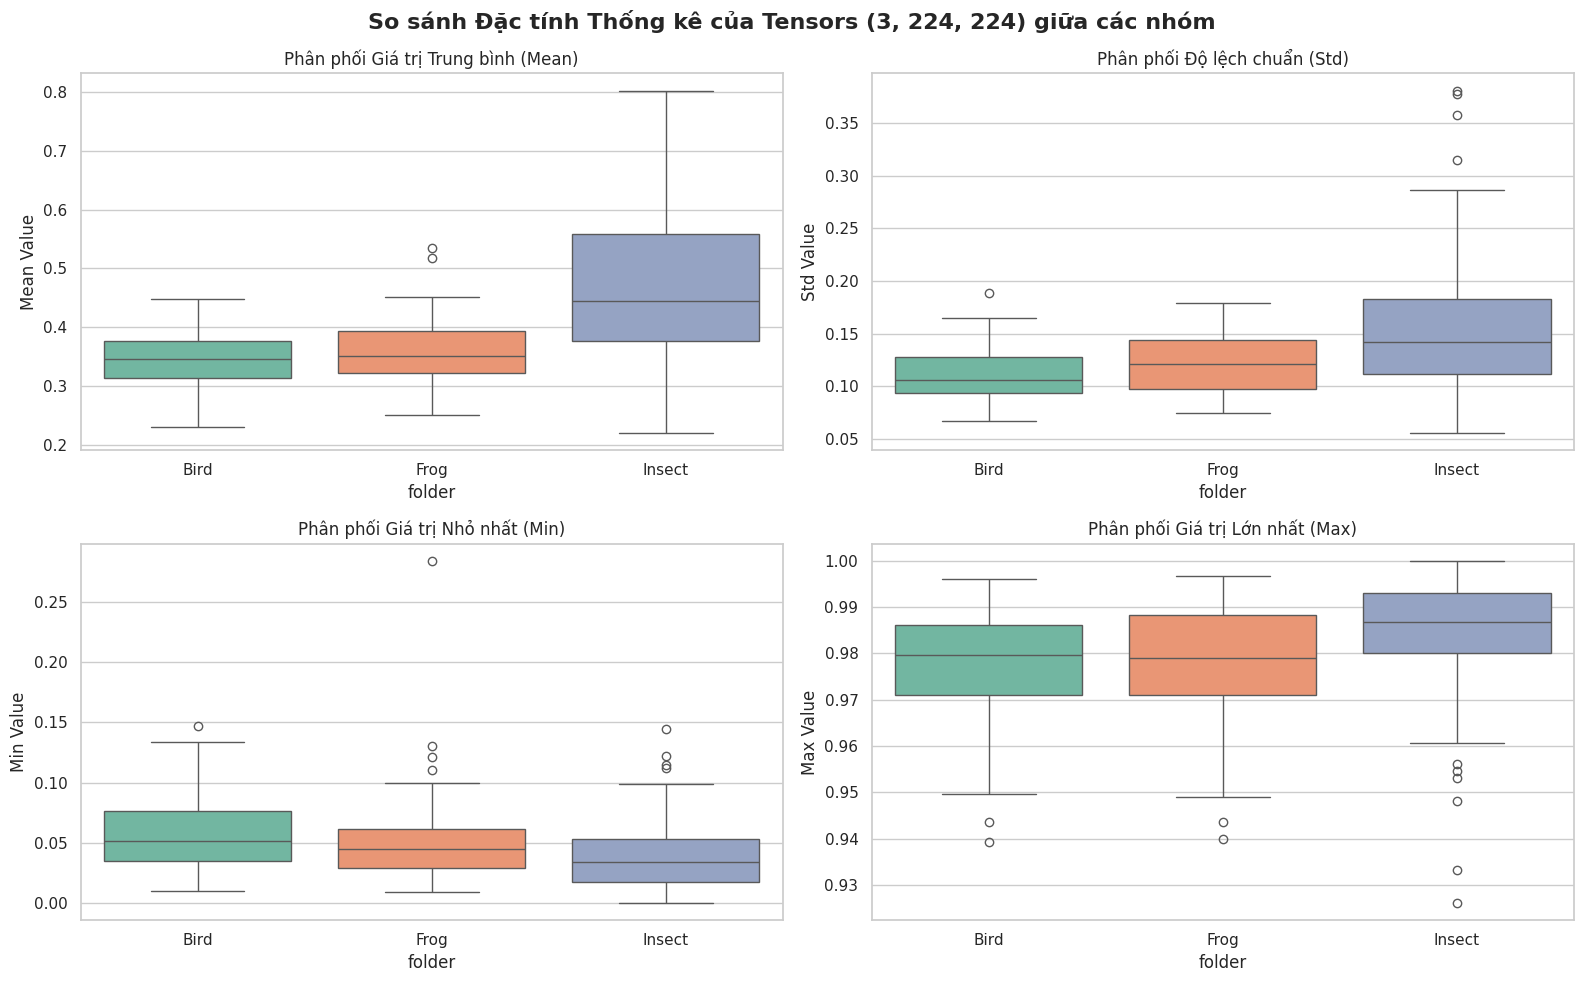

In [5]:
plt.figure(figsize=(16, 10))

# 1. So sánh Mean
plt.subplot(2, 2, 1)
sns.boxplot(data=df_eda, x='folder', y='mean', palette='Set2', hue='folder', legend=False)
plt.title('Phân phối Giá trị Trung bình (Mean)')
plt.ylabel('Mean Value')

# 2. So sánh Std
plt.subplot(2, 2, 2)
sns.boxplot(data=df_eda, x='folder', y='std', palette='Set2', hue='folder', legend=False)
plt.title('Phân phối Độ lệch chuẩn (Std)')
plt.ylabel('Std Value')

# 3. So sánh Min
plt.subplot(2, 2, 3)
sns.boxplot(data=df_eda, x='folder', y='min', palette='Set2', hue='folder', legend=False)
plt.title('Phân phối Giá trị Nhỏ nhất (Min)')
plt.ylabel('Min Value')

# 4. So sánh Max
plt.subplot(2, 2, 4)
sns.boxplot(data=df_eda, x='folder', y='max', palette='Set2', hue='folder', legend=False)
plt.title('Phân phối Giá trị Lớn nhất (Max)')
plt.ylabel('Max Value')

plt.suptitle('So sánh Đặc tính Thống kê của Tensors (3, 224, 224) giữa các nhóm', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Trực quan hóa Spectrogram mẫu của 3 Nhóm

Dưới đây là biểu đồ hiển thị Spectrogram mẫu của Chim, Ếch và Côn trùng (mỗi nhóm lấy ngẫu nhiên 3 mẫu) để kiểm tra độ trực quan và đặc trưng tần số.

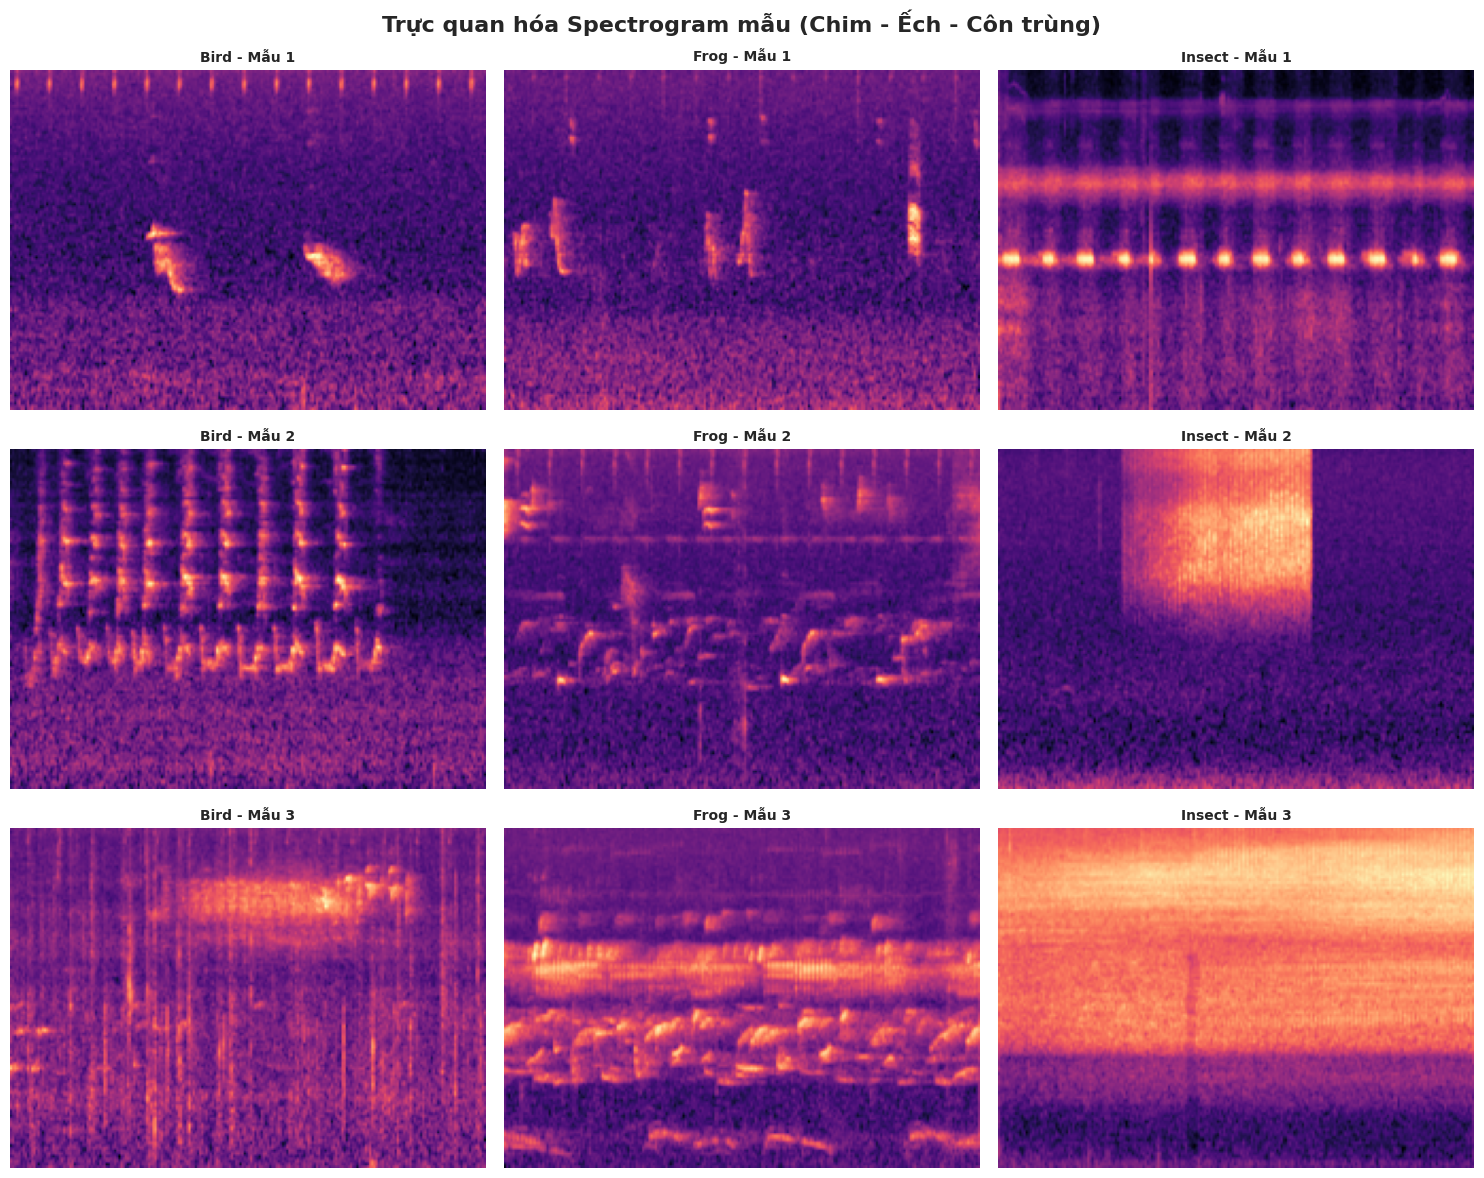

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col_idx, folder in enumerate(folders):
    folder_path = os.path.join(GROUPING_DIR, folder)
    files = stats_summary[folder]
    selected = random.sample(files, 3)

    for row_idx, fname in enumerate(selected):
        fpath = os.path.join(folder_path, fname)
        tensor = torch.load(fpath, map_location='cpu')
        # Lấy kênh đầu tiên để hiển thị spectrogram 2D
        spec_2d = tensor[0].numpy()

        ax = axes[row_idx, col_idx]
        im = ax.imshow(spec_2d, cmap='magma', origin='lower', aspect='auto')
        ax.set_title(f"{folder} - Mẫu {row_idx + 1}", fontsize=10, fontweight='bold')
        ax.axis('off')

plt.suptitle('Trực quan hóa Spectrogram mẫu (Chim - Ếch - Côn trùng)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Kết luận & Đánh giá mức độ sẵn sàng

### 📝 Đánh giá sự tương thích của Dữ liệu:
1. **Đồng nhất Shape:** Toàn bộ dữ liệu của 3 nhóm đều đạt shape **`(3, 224, 224)`** giúp tránh lỗi lệch tensor kích thước đầu vào.
2. **Tính đồng nhất tiền xử lý:** Tất cả các nhóm đều được chuẩn hóa cục bộ về dải **`[0, 1]`** (Min đạt 0.0 và Max đạt 1.0) giúp quá trình tính toán đạo hàm ổn định và EfficientNet học nhanh hơn.
3. **Phân phối Mean & Std:** Nhóm côn trùng (Insect) và chim (Bird) có dải mean/std khá tương tự do đều có đặc điểm tần số trung-cao tuần hoàn. Tập dữ liệu Ếch (Frog) có cấu trúc âm học dạng xung năng lượng (impulse-like) nên có một chút khác biệt phân bố thống kê, điều này là bình thường về mặt sinh học và sẽ giúp mô hình phân biệt tốt hơn.

### 🚀 Bước tiếp theo:
Bạn có thể bắt đầu chạy huấn luyện mô hình Multi-task phiên bản mới bằng cách thay đổi lớp đầu ra `num_species = 4` thay vì 24 trong `BioListenMultiTaskModel`.